In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


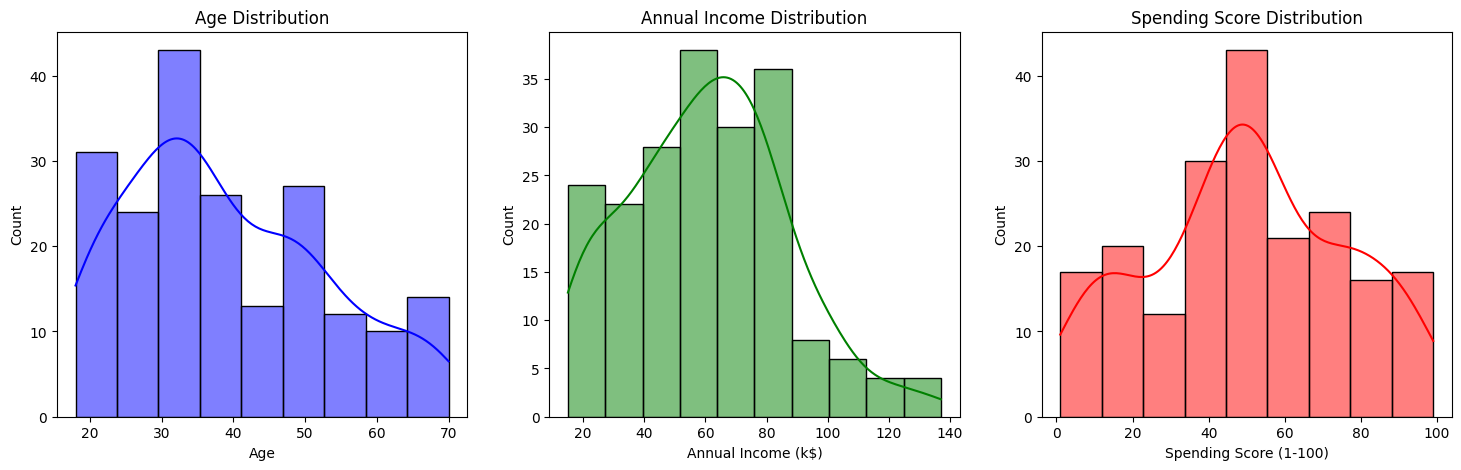

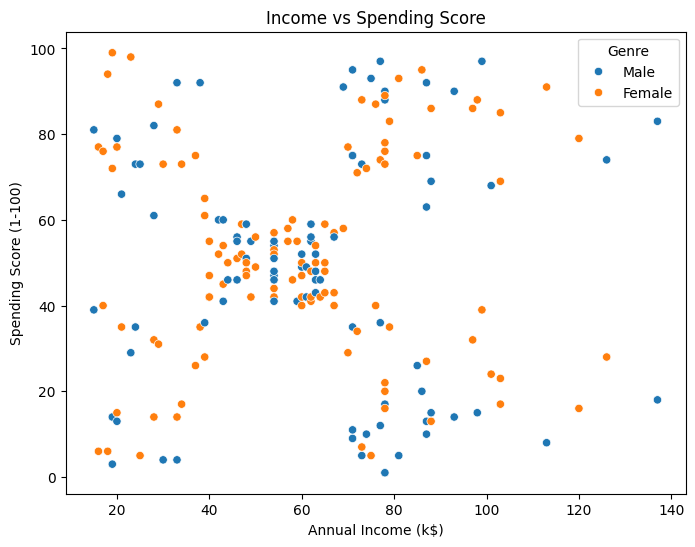

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

# Step 1: Exploratory Data Analysis (EDA)

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue').set_title('Age Distribution')
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='green').set_title('Annual Income Distribution')
sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='red').set_title('Spending Score Distribution')
plt.show()

# Visualize Relationship between Income and Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', data=df)
plt.title('Income vs Spending Score')
plt.show()

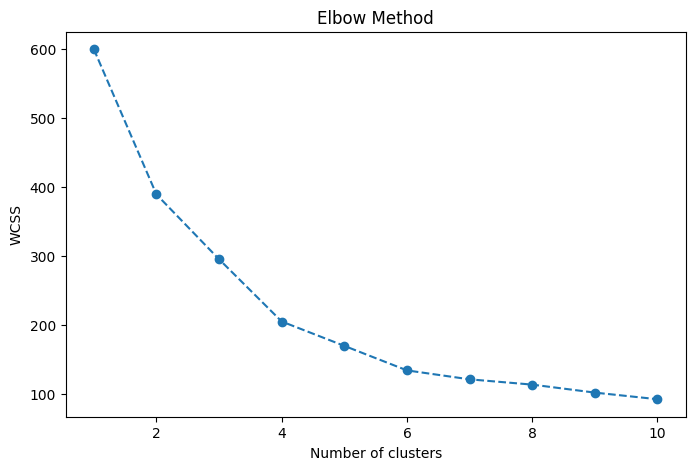

In [ ]:
# Step 2: K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features and Scale
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal k using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Apply K-Means with k=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

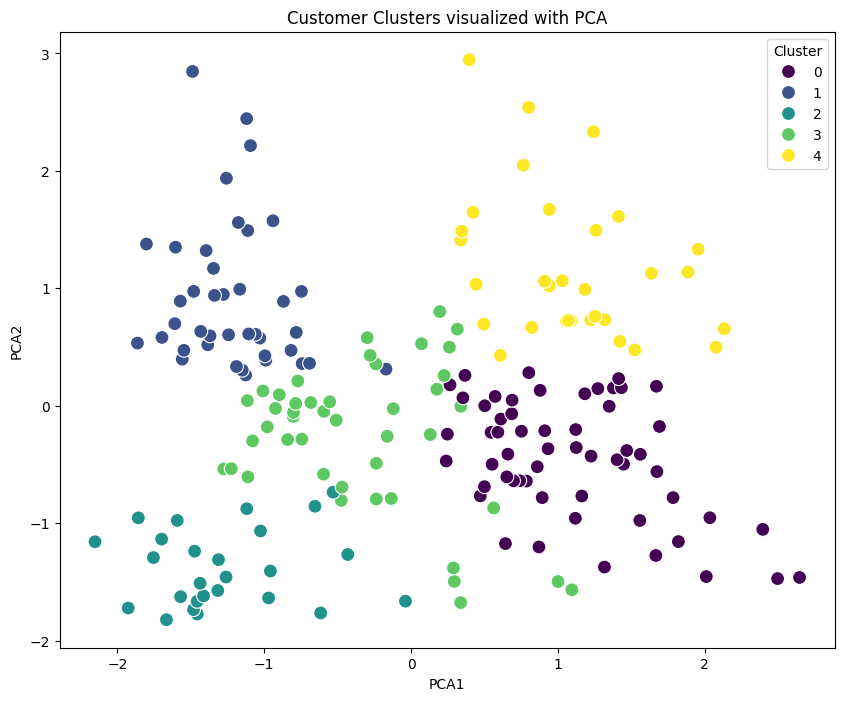

In [ ]:
#  Step 3: Visualization using PCA

from sklearn.decomposition import PCA

# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for visualization
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster']

# Plot clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='viridis', data=df_pca, s=100)
plt.title('Customer Clusters visualized with PCA')
plt.show()